In [3]:
import numpy as np
import dpluspy
import pickle

import matplotlib.pyplot as plt

In [4]:
def run_bootstrap(in_fnames):
    sums = {}
    for fname in in_fnames:
        with open(fname, "rb") as fin:
            chrom_sums = pickle.load(fin)
        sums.update(chrom_sums)

    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]

    replicates = dpluspy.bootstrapping.get_bootstrap_reps(
        sums, num_reps=100, weighted=True, aggregate=True)
    varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
    means = dpluspy.bootstrapping.weighted_means_across_regions(
        sums, aggregate=True)
    

    return bins, pop_ids, means, varcovs


bins, pop_ids, means0, varcovs0 = run_bootstrap(["arm_stats_chr22.pkl"])
bins, pop_ids, means1, varcovs1 = run_bootstrap(["interval_overhang_stats_chr22.pkl"])
bins, pop_ids, means2, varcovs2 = run_bootstrap(["interval_stats_chr22.pkl"])

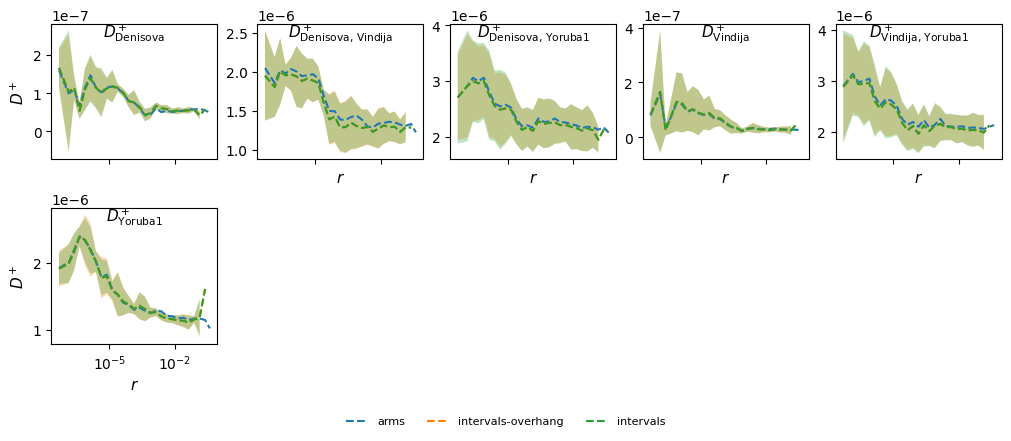

In [6]:
# Plot a summary for five samples
colors = ["tab:blue", "tab:orange", "tab:green"]
labels = ["arms", "intervals-overhang", "intervals"]
dpluspy.plotting.plot_d_plus_curves(means=[means0, means1, means1], 
    varcovs=[varcovs0, varcovs1, varcovs2], bins=bins,
    pop_ids=pop_ids, labels=labels, colors=colors,)